# Decision Trees Refresh: Iris Flowers
## Class Example — Medina County Career Center

**Goal:** Classify iris flowers into 3 species based on petal/sepal measurements.

**Dataset:** Iris from scikit-learn (150 flowers, 4 features, 3 classes) — originally from the UCI ML Repository, but built into sklearn so no internet connection needed.

**The process (same as regression, different model):**
1. Load the data
2. Explore the features
3. Train/test split
4. Build the decision tree
5. Evaluate (accuracy)
6. Visualize the tree
7. Brief mention: Random Forests

## Step 0: Install + Import

In [1]:
# No extra installs needed — Iris is built into scikit-learn
print('Nothing to install — sklearn includes the Iris dataset!')

Nothing to install — sklearn includes the Iris dataset!


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris                        # built-in dataset!
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree    # decision tree!
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('All libraries loaded!')

All libraries loaded!


## Step 1: Load the Data

The Iris dataset has 150 flowers. Each flower has 4 measurements and belongs to one of 3 species:
- **Setosa** — easy to identify
- **Versicolor** — medium
- **Virginica** — similar to versicolor

In [3]:
# Load Iris dataset from sklearn (built-in, no internet needed)
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

X = iris.data       # 4 measurements per flower
y = iris.target     # numeric species codes: 0, 1, 2

# Combine for exploration — map numeric codes to species names
df = X.copy()
df['species'] = y.map(dict(enumerate(iris.target_names)))

print(f'Dataset: {len(df)} flowers, {X.shape[1]} features')
print(f'\nFeatures: {list(X.columns)}')
print(f'\nSpecies counts:')
print(df['species'].value_counts())
print(f'\nFirst 5 rows:')
display(df.head())

Dataset: 150 flowers, 4 features

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Species counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Step 2: Explore the Data

Let's see how the measurements differ across species.

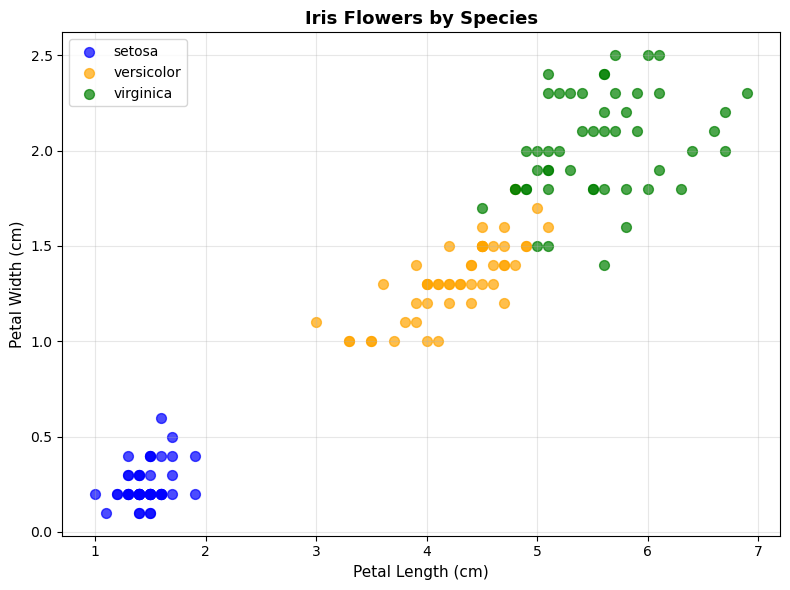

Notice: Setosa is clearly separated!
Versicolor and Virginica overlap a bit — harder to split.


In [4]:
# Scatter plot: petal length vs petal width, colored by species
speciesNames = iris.target_names

plt.figure(figsize=(8, 6))
colors = ['blue', 'orange', 'green']

for i, (name, color) in enumerate(zip(speciesNames, colors)):
    mask = df['species'] == name
    plt.scatter(df.loc[mask, 'petal length (cm)'], df.loc[mask, 'petal width (cm)'],
                label=name, color=color, alpha=0.7, s=50)

plt.xlabel('Petal Length (cm)', fontsize=11)
plt.ylabel('Petal Width (cm)', fontsize=11)
plt.title('Iris Flowers by Species', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Notice: Setosa is clearly separated!')
print('Versicolor and Virginica overlap a bit — harder to split.')

## Step 3: Train/Test Split

Same as regression: 80% train, 20% test.

In [5]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {len(X_train)} flowers')
print(f'Test set:     {len(X_test)} flowers')

Training set: 120 flowers
Test set:     30 flowers


## Step 4: Build the Decision Tree

Instead of `LinearRegression()`, we use `DecisionTreeClassifier()`.

We set `max_depth=3` to keep the tree small enough to understand. Without this, the tree could grow huge and overfit.

In [6]:
# Create and train the decision tree
treeModel = DecisionTreeClassifier(
    max_depth=3,        # limit tree depth to prevent overfitting
    random_state=42
)
treeModel.fit(X_train, y_train)

print('Decision tree trained!')
print(f'Tree depth: {treeModel.get_depth()}')
print(f'Number of leaves (final answers): {treeModel.get_n_leaves()}')

Decision tree trained!
Tree depth: 3
Number of leaves (final answers): 5


## Step 5: Evaluate the Model

In [7]:
# Make predictions on test data
predictions = treeModel.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f'ACCURACY: {accuracy:.2%}')
print(f'  That means {int(accuracy * len(y_test))}/{len(y_test)} flowers classified correctly')

print(f'\nDetailed report:')
print(classification_report(y_test, predictions))

ACCURACY: 100.00%
  That means 30/30 flowers classified correctly

Detailed report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



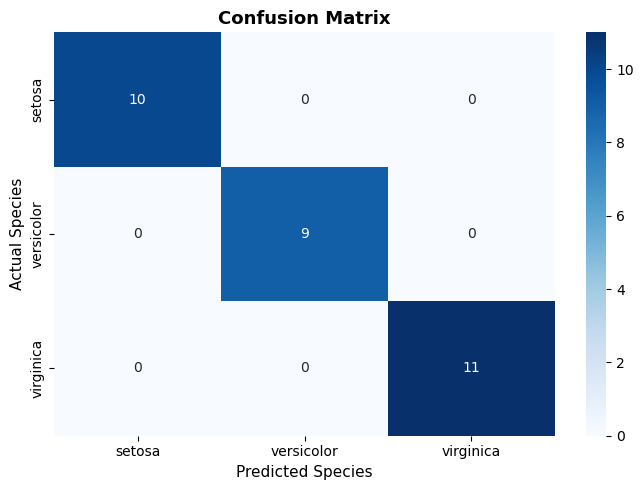

Diagonal = correct predictions
Off-diagonal = mistakes


In [8]:
# Confusion matrix — shows where mistakes happen
speciesNames = iris.target_names
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=speciesNames, yticklabels=speciesNames)
plt.xlabel('Predicted Species', fontsize=11)
plt.ylabel('Actual Species', fontsize=11)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Diagonal = correct predictions')
print('Off-diagonal = mistakes')

## Step 6: Visualize the Tree

This is the best part — we can SEE exactly how the tree makes decisions!

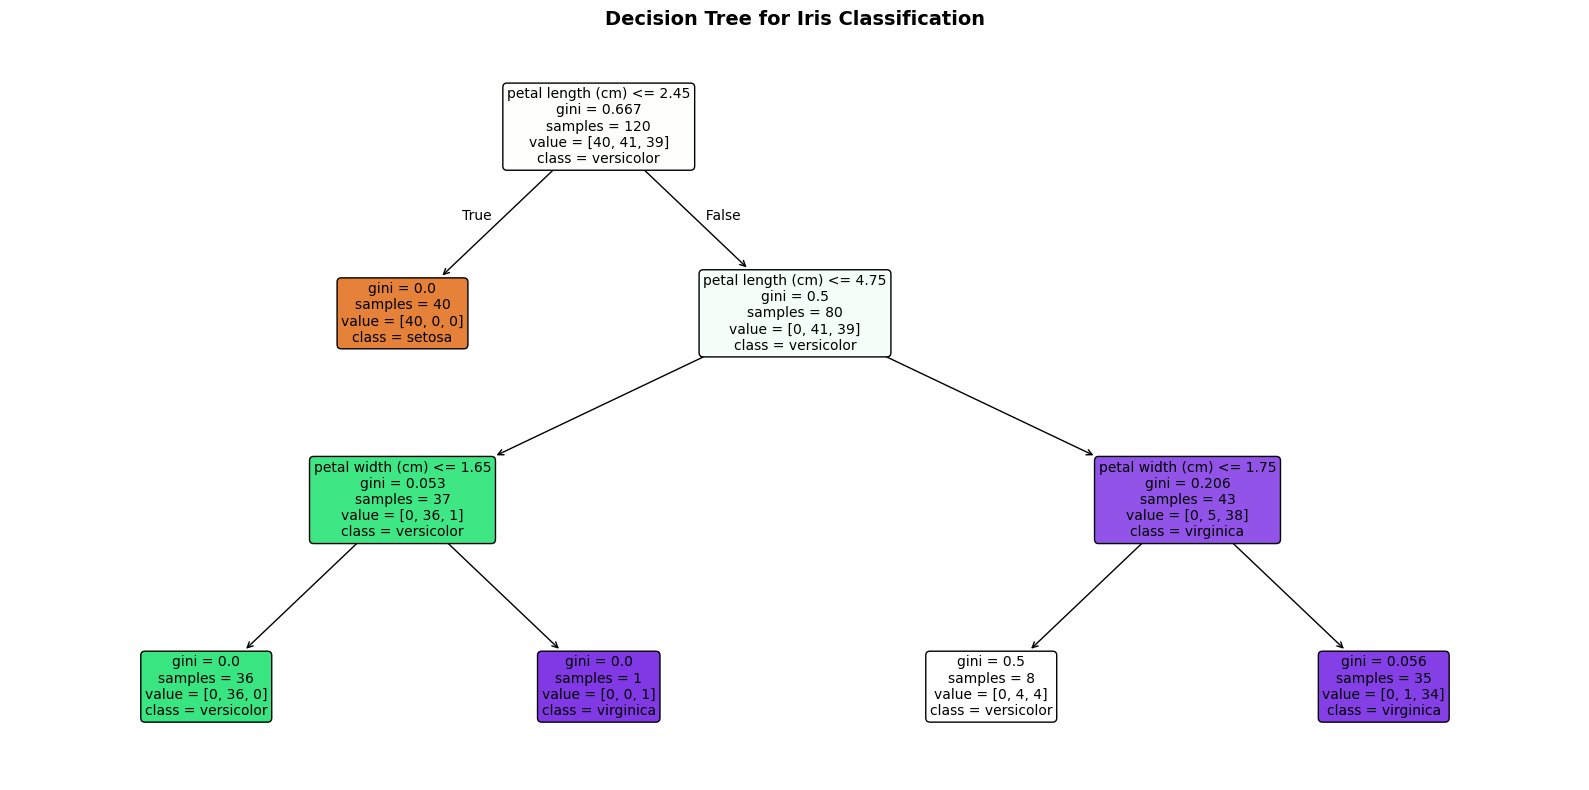

Each box shows:
  - The question (e.g., petal length (cm) <= 2.45)
  - gini = how impure the group is (0 = perfectly pure)
  - samples = how many flowers reach this point
  - value = count of each class [setosa, versicolor, virginica]
  - class = the majority class at this node


In [9]:
# Draw the actual decision tree
speciesNames = list(iris.target_names)
plt.figure(figsize=(16, 8))
plot_tree(treeModel,
          feature_names=list(X.columns),
          class_names=speciesNames,
          filled=True,           # color by class
          rounded=True,          # rounded boxes
          fontsize=10)
plt.title('Decision Tree for Iris Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Each box shows:')
print('  - The question (e.g., petal length (cm) <= 2.45)')
print('  - gini = how impure the group is (0 = perfectly pure)')
print('  - samples = how many flowers reach this point')
print('  - value = count of each class [setosa, versicolor, virginica]')
print('  - class = the majority class at this node')

## Step 7: Feature Importance

Which features does the tree rely on most?

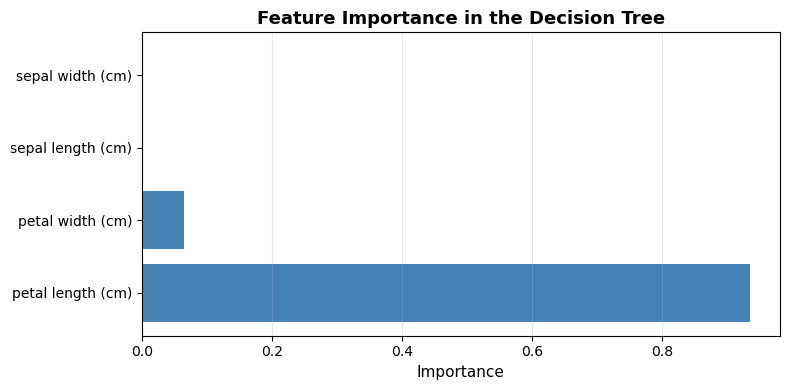

Higher importance = the tree relies on this feature more for splitting


In [10]:
# Feature importance
importanceDf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': treeModel.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(importanceDf['Feature'], importanceDf['Importance'], color='steelblue')
plt.xlabel('Importance', fontsize=11)
plt.title('Feature Importance in the Decision Tree', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Higher importance = the tree relies on this feature more for splitting')

## Quick Note: Random Forests

A **Random Forest** is just a collection of many decision trees that vote together.

In code, you literally just swap one line:

In [11]:
# Random Forest = many trees voting together
from sklearn.ensemble import RandomForestClassifier

# Same process — just a different model
forestModel = RandomForestClassifier(n_estimators=100, random_state=42)
forestModel.fit(X_train, y_train)
forestPredictions = forestModel.predict(X_test)
forestAccuracy = accuracy_score(y_test, forestPredictions)

print(f'Single Decision Tree accuracy: {accuracy:.2%}')
print(f'Random Forest (100 trees) accuracy: {forestAccuracy:.2%}')
print(f'\nRandom Forest = {forestModel.n_estimators} trees voting together')
print('For simple problems like Iris, the improvement is small.')
print('For complex problems, random forests usually win by a lot.')

Single Decision Tree accuracy: 100.00%
Random Forest (100 trees) accuracy: 100.00%

Random Forest = 100 trees voting together
For simple problems like Iris, the improvement is small.
For complex problems, random forests usually win by a lot.


---

## Summary

**What we did:**
1. Loaded the Iris flower dataset (150 flowers, 4 features, 3 classes)
2. Explored with scatter plots — saw that species form natural clusters
3. Built a Decision Tree that asks yes/no questions to classify flowers
4. Evaluated with accuracy and a confusion matrix
5. Visualized the actual tree — we can READ how it makes decisions
6. Showed that Random Forest = many trees voting together (one line change)

**Key differences from regression:**
- Regression predicts a NUMBER → Classification predicts a CATEGORY
- R² and MAE → Accuracy and Confusion Matrix
- LinearRegression() → DecisionTreeClassifier()
- But the PROCESS is the same: load → clean → split → build → evaluate